<h1>1. Import Library</h1>

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# from google.colab import drive
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import cv2
import torch
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from tqdm import tqdm
import time
import random

current_path = os.getcwd()
print(current_path)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # multi-GPU

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")


Training on device: cuda


In [ ]:
Configs = {
    "dataset": f"{current_path}/CarTreeSatelliteDataset",
    "batch_size": 32,
    "img_size": 64,
    "hidden_layers": [512, 256, 128],
    "lr": 0.001,
    "epochs": 15,
    "saveWeightPath": f"{current_path}/best_model_torch.pth"
}
print(Configs)

<h1>2. Review And Loading Data</h1>

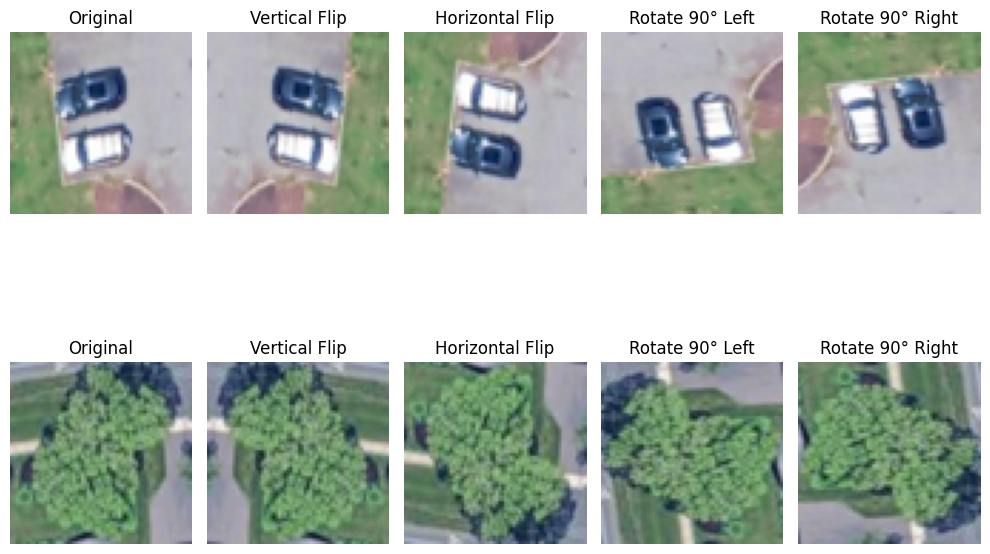

In [ ]:
carImg = Image.open(f"{Configs['dataset']}/train/cars/1.png").resize((Configs["img_size"], Configs["img_size"]))
carVFlip = Image.open(f"{Configs['dataset']}/train/cars/1+_VFlip.png").resize((Configs["img_size"], Configs["img_size"]))
carHFlip = Image.open(f"{Configs['dataset']}/train/cars/1+_HFlip.png").resize((Configs["img_size"], Configs["img_size"]))
car90RF = Image.open(f"{Configs['dataset']}/train/cars/1+rl90.png").resize((Configs["img_size"], Configs["img_size"]))
car90RR = Image.open(f"{Configs['dataset']}/train/cars/1+rr90.png").resize((Configs["img_size"], Configs["img_size"]))

treeImg = Image.open(f"{Configs['dataset']}/train/trees/1.png").resize((Configs["img_size"], Configs["img_size"]))
treeVFlip = Image.open(f"{Configs['dataset']}/train/trees/1+_VFlip.png").resize((Configs["img_size"], Configs["img_size"]))
treeHFlip = Image.open(f"{Configs['dataset']}/train/trees/1+_HFlip.png").resize((Configs["img_size"], Configs["img_size"]))
tree90RF = Image.open(f"{Configs['dataset']}/train/trees/1+rl90.png").resize((Configs["img_size"], Configs["img_size"]))
tree90RR = Image.open(f"{Configs['dataset']}/train/trees/1+rr90.png").resize((Configs["img_size"], Configs["img_size"]))
plt.figure(figsize=(10,8))

plt.subplot(2,5,1)
plt.imshow(carImg)
plt.title("Original")
plt.axis("off")

plt.subplot(2,5,2)
plt.imshow(carVFlip)
plt.title("Vertical Flip")
plt.axis("off")

plt.subplot(2,5,3)
plt.imshow(carHFlip)
plt.title("Horizontal Flip")
plt.axis("off")

plt.subplot(2,5,4)
plt.imshow(car90RF)
plt.title("Rotate 90° Left")
plt.axis("off")

plt.subplot(2,5,5)
plt.imshow(car90RR)
plt.title("Rotate 90° Right")
plt.axis("off")


plt.subplot(2,5,6)
plt.imshow(treeImg)
plt.title("Original")
plt.axis("off")

plt.subplot(2,5,7)
plt.imshow(treeVFlip)
plt.title("Vertical Flip")
plt.axis("off")

plt.subplot(2,5,8)
plt.imshow(treeHFlip)
plt.title("Horizontal Flip")
plt.axis("off")

plt.subplot(2,5,9)
plt.imshow(tree90RF)
plt.title("Rotate 90° Left")
plt.axis("off")

plt.subplot(2,5,10)
plt.imshow(tree90RR)
plt.title("Rotate 90° Right")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import os

transform = transforms.Compose([
    transforms.Resize((Configs["img_size"], Configs["img_size"])),
    transforms.ToTensor(),
  #  transforms.Lambda(lambda x: x / 255.0)
])

class ImageFolderCustom(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        for label, category in enumerate(['cars', 'trees']):
            category_path = os.path.join(root_dir, category)
            for file_name in os.listdir(category_path):
                  self.images.append(os.path.join(category_path, file_name))
                  self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        image = Image.open(img_name).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

# Load datasets
train_data = ImageFolderCustom(root_dir=os.path.join(Configs['dataset'], 'train'), transform=transform)
val_data = ImageFolderCustom(root_dir=os.path.join(Configs['dataset'], 'val'), transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

<h1>3. Setup Model</h1>

In [ ]:
import torch
import torch.nn as nn

# Example Configs
input_size = Configs["img_size"] * Configs["img_size"] * 3  # 3 channels RGB

class FlexibleMLP(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super(FlexibleMLP, self).__init__()

        layers = [nn.Flatten()]
        in_features = input_size

        # Create hidden layers dynamically
        for h in hidden_layers:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h

        # Output layer for binary classification
        layers.append(nn.Linear(in_features, 1))
        layers.append(nn.Sigmoid())  # for probability

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Instantiate model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = FlexibleMLP(input_size=input_size, hidden_layers=Configs['hidden_layers']).to(device)

print(model)


FlexibleMLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=1, bias=True)
    (8): Sigmoid()
  )
)


<h1>4. Setup training Strategies</h1>

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=Configs['lr'])
scheduler = StepLR(optimizer, step_size=5, gamma=0.9)
loss_fn = nn.BCELoss()

In [ ]:
# Training loop
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    train_correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predicted = (outputs > 0.5).float()
        train_correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), train_correct / total

# Evaluation
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    val_correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in tqdm(loader, desc="Evaluating", leave=False):
          images = images.to(device)
          labels = labels.float().unsqueeze(1).to(device)  # [batch,1] for BCELoss

          outputs = model(images)
          loss = loss_fn(outputs, labels)

          total_loss += loss.item()

          predicted = (outputs > 0.5).float()
          val_correct += (predicted == labels).sum().item()
          total += labels.size(0)
    return total_loss / len(loader), val_correct / total

In [ ]:
train_acc_list = []
train_loss_list = []
val_acc_list = []
val_loss_list = []
best_val_acc = -1

for epoch in range(1, Configs['epochs'] + 1):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)

    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), Configs['saveWeightPath'])
        print(f"Best model saved at epoch {epoch} with validation accuracy: {val_acc:.4f}")

    scheduler.step()

    end_time = time.time()
    total_time = end_time - start_time
    print(
        f"Epoch {epoch:02d}: "
        f"train_loss: {train_loss:.4f}, train_acc: {train_acc*100:.2f}% | "
        f"val_loss: {val_loss:.4f}, val_acc: {val_acc*100:.2f}% | "
        f"total time taken: {total_time:.4f}"
    )

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

print("Progress: ")
print(f"train_acc_list: {train_acc_list}")
print(f"train_loss_list: {train_loss_list}")
print(f"val_acc_list: {val_acc_list}")
print(f"val_loss_list: {val_loss_list}")

Best model saved at epoch 1 with validation accuracy: 0.6750
Epoch 01: train_loss: 0.1441, train_acc: 94.81% | val_loss: 0.8273, val_acc: 67.50% | total time taken: 89.3554


Best model saved at epoch 2 with validation accuracy: 0.7625
Epoch 02: train_loss: 0.0604, train_acc: 97.62% | val_loss: 0.5409, val_acc: 76.25% | total time taken: 9.0126


Epoch 03: train_loss: 0.0878, train_acc: 96.50% | val_loss: 0.6647, val_acc: 73.25% | total time taken: 9.4354


Epoch 04: train_loss: 0.0969, train_acc: 96.44% | val_loss: 0.5749, val_acc: 74.75% | total time taken: 8.8746


Epoch 05: train_loss: 0.1444, train_acc: 93.38% | val_loss: 0.7853, val_acc: 63.00% | total time taken: 8.7276


...

Epoch 11: train_loss: 0.0409, train_acc: 98.50% | val_loss: 0.4338, val_acc: 84.25% | total time taken: 9.2174


Best model saved at epoch 12 with validation accuracy: 0.8500
Epoch 12: train_loss: 0.0308, train_acc: 98.81% | val_loss: 0.5019, val_acc: 85.00% | total time taken: 8.8095


Epoch 13: train_loss: 0.2432, train_acc: 90.88% | val_loss: 0.4731, val_acc: 68.00% | total time taken: 9.1658


Epoch 14: train_loss: 0.0862, train_acc: 96.94% | val_loss: 0.4157, val_acc: 81.00% | total time taken: 9.0006


Epoch 15: train_loss: 0.0448, train_acc: 98.31% | val_loss: 0.6722, val_acc: 68.75% | total time taken: 8.9321
Progress: 
train_acc_list: [0.948125, 0.97625, 0.965, 0.964375, 0.93375, 0.948125, 0.95875, 0.97, 0.98375, 0.97625, 0.985, 0.988125, 0.90875, 0.969375, 0.983125]
train_loss_list: [0.1441116711869836, 0.06038160761352628, 0.08781325130723416, 0.09694038873771206, 0.14441140759270638, 0.11367094043642283, 0.09882131296442821, 0.07746803561458364, 0.03833463878836483, 0.06183992086909711, 0.0408916199253872, 0.030825369644444437, 0.24320037344819867, 0.08622579552233219, 0.0447703252651263]
val_acc_list: [0.675, 0.7625, 0.7325, 0.7475, 0.63, 0.6725, 0.8475, 0.795, 0.8275, 0.7275, 0.8425, 0.85, 0.68, 0.81, 0.6875]
val_loss_list: [0.8273132181762216, 0.5408949681486075, 0.6647010873644971, 0.5749189666329095, 0.785281185956242, 0.6553928103083029, 0.6014097909053538, 0.4438603376111132, 0.397661286263061, 0.6674167826377715, 0.4337516070092846, 0.5019248429900762, 0.473067308847720

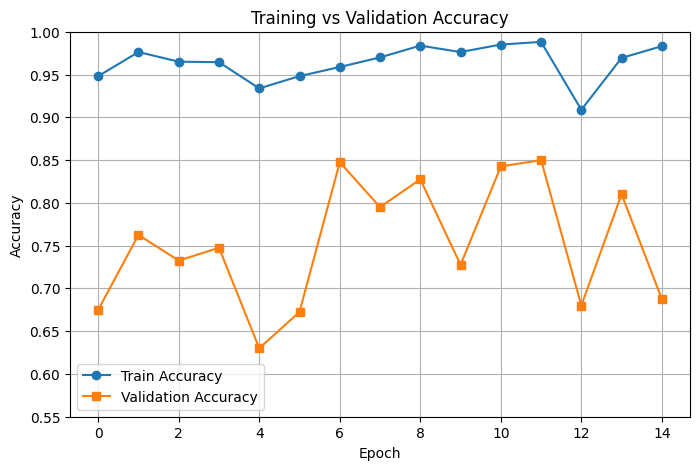

In [ ]:
# X-axis: index of each epoch or step
x = list(range(len(train_acc_list)))

plt.figure(figsize=(8,5))
plt.plot(x, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(x, val_acc_list, marker='s', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.grid(True)
plt.legend()
plt.ylim(0.55, 1)
plt.show()


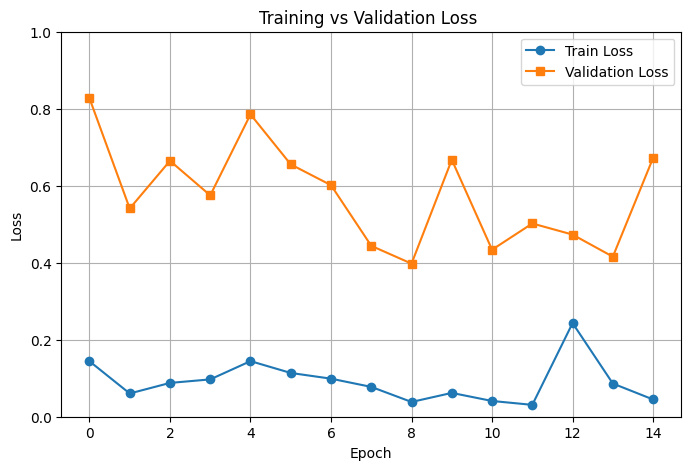

In [ ]:
import matplotlib.pyplot as plt

# X-axis: index of each epoch or step
x = list(range(len(train_loss_list)))

plt.figure(figsize=(8,5))
plt.plot(x, train_loss_list, marker='o', label='Train Loss')
plt.plot(x, val_loss_list, marker='s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss ')
plt.grid(True)
plt.legend()
plt.ylim(0, 1)
plt.show()


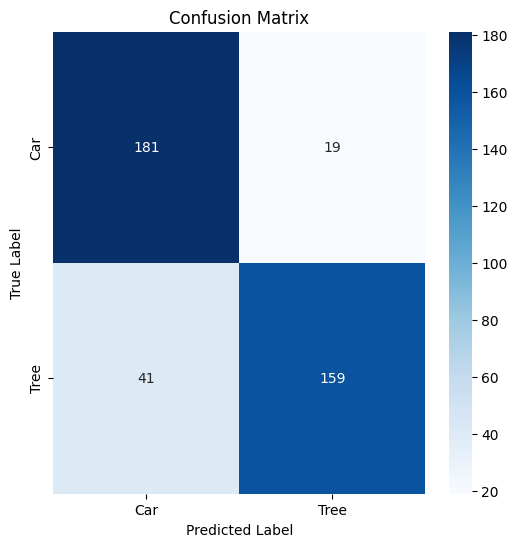

Classification Report:
              precision    recall  f1-score   support

         Car       0.82      0.91      0.86       200
        Tree       0.89      0.80      0.84       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [ ]:
best_model_path = Configs["saveWeightPath"]
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

y_true = []
y_pred = []

for images, labels in val_loader:
    images = images.to(device)
    labels = labels.float().unsqueeze(1).to(device)  # [batch,1] for BCELoss

    outputs = model(images)
    predicted = (outputs > 0.5).float()

    y_true.extend(labels.cpu().numpy())      # move to CPU, convert to numpy
    y_pred.extend(predicted.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Car', 'Tree'], yticklabels=['Car', 'Tree'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

report = classification_report(y_true, y_pred, target_names=['Car', 'Tree'])
print("Classification Report:")
print(report)

<h1>5. Real Test</h1>

In [ ]:
pathRealImages = os.path.join(Configs["dataset"], "realTest")

In [ ]:
real_images = []
y_true = []
y_pred = []

testImagePaths = [os.path.join(Configs["dataset"], "realTest", x) for x in os.listdir(pathRealImages)]
print(f"total images for test: {len(testImagePaths)}")

model.eval()
with torch.no_grad():
    for path in testImagePaths:
        image = Image.open(path).convert("RGB")
        image = transform(image)
        image = image.to(device)

        y_true.append(1 if "/tree" in path.lower() else 0)
        real_images.append(image)
        preds = model(image.unsqueeze(0))
        predicted_class = (preds > 0.5).long().cpu().item()
        y_pred.append(predicted_class)


total images for test: 10


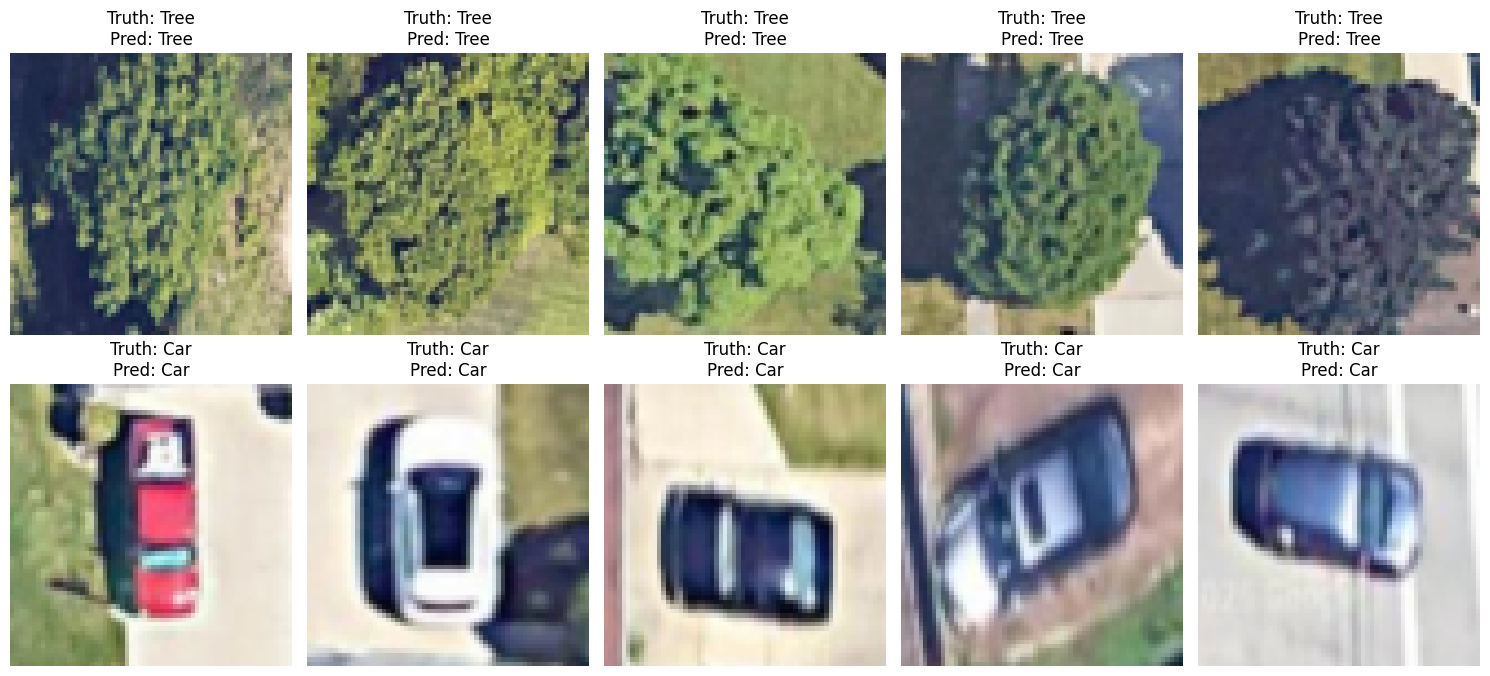

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


num_images_to_display = 10
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

axes = axes.flatten()

for i in range(num_images_to_display):
    ax = axes[i]

    img = real_images[i].cpu().permute(1, 2, 0).numpy()  # [H, W, 3]

    true_label = 'Tree' if y_true[i] == 1 else 'Car'
    pred_label = 'Tree' if y_pred[i] == 1 else 'Car'

    # Display image
    ax.imshow(img)
    ax.set_title(f"Truth: {true_label}\nPred: {pred_label}")
    ax.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# /content/drive/MyDrive/ColabNotebooks/CarTreeSatellite/val/cars/159.png